# Teaching a Computer to Recognize Handwritten Numbers


---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h1 style="margin-top:0;"> تعليم الحاسوب التعرّف على الأرقام المكتوبة بخط اليد</h1>
</div>

## Step 1 — Get our tools

**PyTorch** is a free library that does all the heavy math for us. We also grab **matplotlib**,
which lets us draw pictures so we can actually *see* the digits.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 1 — نجهّز أدواتنا </h2>
<p><strong>بايتورش (PyTorch)</strong> مكتبة مجانية تقوم بكل العمليات الحسابية الثقيلة نيابةً عنّا. كما نستعين بمكتبة <strong>matplotlib</strong> التي تتيح لنا رسم الصور حتى نتمكّن فعليًا من <em>رؤية</em> الأرقام.</p>
</div>

In [ ]:
# نجهّز الأدوات التي سنستخدمها
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

## Step 2 — The MNIST dataset

**MNIST** is a famous free collection of **70,000 tiny pictures of handwritten digits**, each
labeled with the correct number. Each picture is **28 × 28 pixels**.

We split them into two piles:
- **Training set (60,000)** — the flashcards our brain practices on.
- **Test set (10,000)** — images it has *never seen*, to check if it truly learned.

`ToTensor()` just turns each picture into numbers the computer can do math with.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 2 —    (بيانات MNIST) </h2>
<p><strong>MNIST</strong> مجموعة مجانية شهيرة تحوي <strong>70,000 صورة صغيرة لأرقام مكتوبة بخط اليد</strong>، كل صورة مصحوبة بالرقم الصحيح، وحجم كل صورة <strong>28 × 28 بكسل</strong>.</p>
<p>نقسمها إلى كومتين:</p>
<ul style="padding-right:22px; margin:0;">
<li style="margin-bottom:6px;"><strong>مجموعة التدريب (60,000):</strong> البطاقات التي يتمرّن عليها النموذج.</li>
<li style="margin-bottom:6px;"><strong>مجموعة الاختبار (10,000):</strong> صور <em>لم يرها النموذج من قبل</em>، للتأكد من أنه تعلّم فعلًا.</li>
</ul>
<p style="margin-top:10px; margin-bottom:0;">الأمر <code>ToTensor()</code> يحوّل كل صورة إلى أرقام يستطيع الحاسوب إجراء العمليات عليها.</p>
</div>

In [ ]:
# نحمّل الصور ونجهّزها في دفعات صغيرة (batches)
transform = transforms.ToTensor()   # picture -> numbers / صورة إلى أرقام

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# A "loader" hands the images to the network in small groups (batches).
train_loader = DataLoader(train_dataset, batch_size=64,   shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

print("\nTraining images / صور التدريب:", len(train_dataset))
print("Test images / صور الاختبار:   ", len(test_dataset))


Training images / صور التدريب: 60000
Test images / صور الاختبار:    10000


### Let's look at some images

Run this cell — you should see 10 little handwritten digits with their correct labels.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h3 style="margin-top:0;">لنلقِ نظرة على بعض الصور </h3>
<p style="margin-bottom:0;">شغّل هذه الخلية — من المفترض أن ترى 10 أرقام صغيرة مكتوبة بخط اليد مع إجاباتها الصحيحة.</p>
</div>

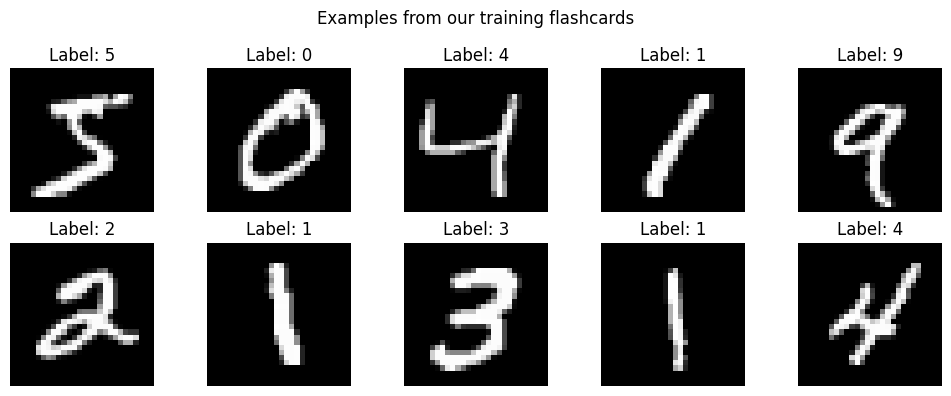

In [ ]:
# نعرض 10 صور مع إجاباتها الصحيحة
plt.figure(figsize=(10, 4))
for i in range(10):
    image, label = train_dataset[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(image[0], cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.suptitle("Examples from our training flashcards")
plt.tight_layout()
plt.show()

## Step 3 — Build the "brain"

Our brain is a stack of simple layers. Information flows through it top to bottom:

- **Flatten** — the image is a 28×28 grid. We unroll it into one long line of
  `28 × 28 = 784` numbers.
- **fc1 (first layer): 784 → 128** — mixes the 784 pixel-numbers into 128 "clues"
  the network invents (curves, edges, loops...).
- **fc2 (last layer): 128 → 10** — turns the clues into **10 final scores**, one per digit (0–9).
  The highest score is the network's guess.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 3 — نبني «الدماغ» </h2>
<p>النموذج مجموعة من الطبقات البسيطة المتراصّة، تتدفّق المعلومات خلالها من الأعلى إلى الأسفل:</p>
<ul style="padding-right:22px; margin:0;">
<li style="margin-bottom:8px;"><strong>Flatten (التسطيح):</strong> الصورة شبكة 28×28، نفردها إلى مصفوفة من <code>28 × 28 = 784</code> رقمًا.</li>
<li style="margin-bottom:8px;"><strong>fc1 (الطبقة الأولى): 784 ← 128:</strong> تتحول أرقام البكسل الـ784 في 128 بكسل تعتبر «دليلًا» تبتكرها الشبكة بنفسها (انحناءات، حواف، حلقات...).</li>
<li style="margin-bottom:0;"><strong>fc2 (الطبقة الأخيرة): 128 ← 10:</strong> تحوّل الأدلّة إلى <strong>10 تصانيف نهائية</strong>، واحدة لكل رقم (0 حتى 9). الرقم صاحب أعلى درجة هو توقع الشبكة.</li>
</ul>
</div>

In [ ]:
# تعريف بنية الشبكة (الدماغ)
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()        # 28x28 grid -> vector of 784 value
        self.fc1     = nn.Linear(784, 128) # layer 1
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(128, 10)  # layer 2 -> 10 scores

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

## Step 4 — Set up the learning rules 📏

Right now our brain is empty and guesses randomly. To help it improve we need two things:

- **The "grader" (loss)** — measures **how wrong** each guess was, as one number. **Big = very
  wrong, small = doing great.** Our goal is to make it as small as possible.
- **The "coach" (optimizer)** — nudges the brain's internal knobs to reduce the mistake. The
  `lr=0.001` is how big each nudge is.

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 4 — نضع قواعد التعلّم 📏</h2>
<p>دماغنا الآن فارغ ويخمّن عشوائيًا. ولمساعدته على التحسّن نحتاج شيئين:</p>
<ul style="padding-right:22px; margin:0;">
<li style="margin-bottom:8px;"><strong>«المصحّح» (الخسارة):</strong> يقيس <strong>مقدار خطأ</strong> كل تخمين برقم واحد. كبير = خطأ كبير، صغير = أداء ممتاز. هدفنا تصغيره قدر الإمكان.</li>
<li style="margin-bottom:0;"><strong>«المدرّب» (المُحسِّن):</strong> يعدّل مقابض الدماغ الداخلية (النموذج) لتقليل الخطأ. والقيمة <code>lr=0.001</code> هي حجم كل تعديل.</li>
</ul>
</div>

In [ ]:
# ننشئ الدماغ ونجهّز «المصحّح» و«المدرّب»
model     = SimpleNN()
criterion = nn.CrossEntropyLoss()                     # the grader / المصحّح
optimizer = optim.Adam(model.parameters(), lr=0.001)  # the coach / المدرّب

## Step 5 — Train the brain!

We go through all the training images **3 times** (each full pass is called an **epoch**). For every
small group of images, the network repeats 4 steps:

1. **Guess** — run the images through the brain.
2. **Grade** — the loss measures how wrong the guesses were.
3. **Find the fix** — `loss.backward()` works out which weights to adjust.
4. **Fix the Weights** — `optimizer.step()` makes the adjustment.

Watch the **loss** after each epoch — it should go **down**.
*(This may take a minute or two — that's normal!)*

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 5 — ندرّب الدماغ! </h2>
<p>نمرّ على كل صور التدريب <strong>3 مرات</strong> (كل جولة كاملة تُسمّى <strong> epoch</strong>). ولكل مجموعة صغيرة من الصور، تكرّر الشبكة 4 خطوات:</p>
<ol style="padding-right:22px; margin:0;">
<li style="margin-bottom:6px;"><strong>التخمين:</strong> تمرير الصور عبر الدماغ.</li>
<li style="margin-bottom:6px;"><strong>التصحيح:</strong> تقيس الخسارة مقدار الخطأ.</li>
<li style="margin-bottom:6px;"><strong>إيجاد التصحيح:</strong> <code>loss.backward()</code> يحسب أي الأوزان نعدّل.</li>
<li style="margin-bottom:0;"><strong>تعديل الأوزان:</strong> <code>optimizer.step()</code> ينفّذ التعديل.</li>
</ol>
<p style="margin-top:10px; margin-bottom:0;">راقب <strong>الخسارة</strong> بعد كل epoch — يجب أن تنخفض.  <em>(قد يستغرق دقيقة أو دقيقتين، وهذا طبيعي!)</em></p>
</div>

In [ ]:
# حلقة التدريب: نكرّر التعلّم على كل الصور 3 مرات
epochs = 3
print("Training started... / بدأ التدريب...\n")

for epoch in range(epochs):
    running_loss = 0.0
    for images, answers in train_loader:
        scores = model(images)              # 1. guess / خمّن
        loss   = criterion(scores, answers) # 2. grade / صحّح

        optimizer.zero_grad()               # reset before the fix
        loss.backward()                     # 3. find the fix / احسب التصحيح
        optimizer.step()                    # 4. Fix / عدّل

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}  —  Loss / الخسارة: {running_loss/len(train_loader):.4f}")

print("\nDone training! / انتهى التدريب! 🎓")

Training started... / بدأ التدريب...

Epoch 1/3  —  Loss / الخسارة: 0.3476
Epoch 2/3  —  Loss / الخسارة: 0.1605
Epoch 3/3  —  Loss / الخسارة: 0.1113

Done training! / انتهى التدريب! 🎓


## Step 6 — The final exam

Did the brain really *learn*, or just memorize? We test it on the **10,000 images it has never
seen**. For each one we take the digit with the **highest score** as its answer, then count how
many are right.

**Accuracy** = correct ÷ total × 100. Expect around **96%** — amazing for so few lines!

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 6 — الاختبار النهائي </h2>
<p>هل تعلّم الدماغ فعلًا أم أنه حفظ فقط؟ نختبره على <strong>10,000 صورة لم يرها من قبل</strong>. لكل صورة نأخذ الرقم صاحب <strong>أعلى درجة</strong> كإجابة، ثم نحسب عدد الإجابات الصحيحة.</p>
<p style="margin-bottom:0;"><strong>الدقّة</strong> = الصحيح ÷ الإجمالي × 100. توقّع نتيجة حوالي <strong>96%</strong> — وهذا مذهل لأسطر قليلة!</p>
</div>

In [ ]:
# نختبر الدماغ على صور لم يرها ونحسب الدقّة
correct = 0
total   = 0
for images, answers in test_loader:
    scores = model(images)
    _, predictions = scores.max(1)          # the highest-scoring digit
    correct += (predictions == answers).sum().item()
    total   += answers.size(0)

print(f"Correct / الصحيح: {correct} / {total}")
print(f"Accuracy / الدقّة: {correct/total*100:.2f}%")

Correct / الصحيح: 9665 / 10000
Accuracy / الدقّة: 96.65%


## Step 7 — See it in action! 🔍

Let's *watch* the brain guess. Below are 10 test images with its predictions.

- **Green title** = correct ✅
- **Red title** = wrong ❌ (messy 4s, 9s and 7s often trip it up — just like they do us!)

---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h2 style="margin-top:0;">الخطوة 7 — لنشاهده يعمل! 🔍</h2>
<p>لنشاهد الدماغ وهو يخمّن. في الأسفل 10 صور اختبار مع توقّع الشبكة.</p>
<ul style="padding-right:22px; margin:0;">
<li style="margin-bottom:6px;"><strong>عنوان أخضر</strong> = صحيح ✅</li>
<li style="margin-bottom:0;"><strong>عنوان أحمر</strong> = خطأ ❌ (غالبًا ما تربكه الأرقام 4 و9 و7 غير الواضحة، تمامًا كما تربكنا!)</li>
</ul>
<p style="margin-top:10px; margin-bottom:0; color:#5b6b7b; font-size:0.95em;">(عناوين الصور بالإنجليزية عمدًا، لأن مكتبة الرسم لا تعرض الحروف العربية بشكل صحيح دون إعداد إضافي.)</p>
</div>

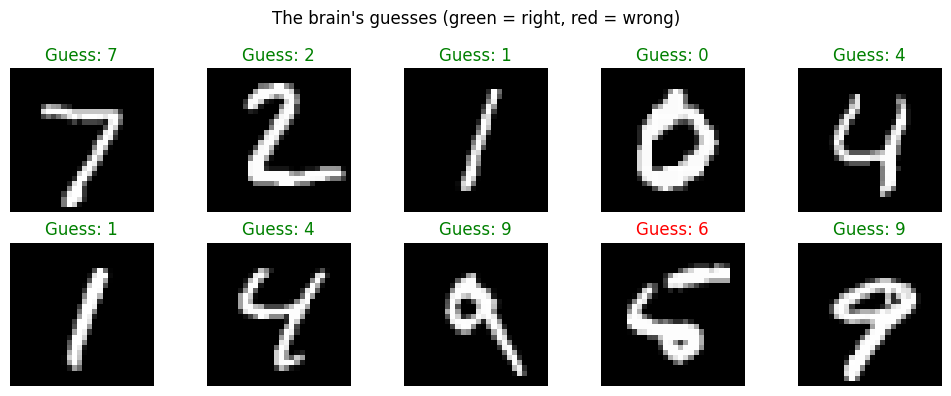

In [ ]:
# نعرض 10 صور مع تخمين الشبكة (أخضر = صحيح، أحمر = خطأ)
images, answers = next(iter(test_loader))
scores = model(images)
_, predictions = scores.max(1)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i][0], cmap='gray')
    color = 'green' if predictions[i] == answers[i] else 'red'
    plt.title(f"Guess: {predictions[i].item()}", color=color)
    plt.axis('off')
plt.suptitle("The brain's guesses (green = right, red = wrong)")
plt.tight_layout()
plt.show()



### Try changing one thing and re-running:
1. **More practice:** `epochs = 3` → `epochs = 5`. Does accuracy go up?
2. **A bigger brain:** change `128` to `256` in `fc1`/`fc2`.
3. **Coaching speed:** change `lr=0.001` to `lr=0.01`.


---

<div dir="rtl" lang="ar" style="text-align:right; direction:rtl; font-family:"Segoe UI",Tahoma,"Noto Naskh Arabic","Traditional Arabic",sans-serif; font-size:1.08em; line-height:2; background:#f6f8fb; border-right:5px solid #3b82c4; padding:16px 22px; border-radius:10px; margin-top:14px; color:#1a2733;">
<h3 style="margin-bottom:6px;">جرّب تغيير شيء واحد وأعد التشغيل:</h3>
<ol style="padding-right:22px; margin:0;">
<li style="margin-bottom:6px;"><strong>تمرّن أكثر:</strong> <code>epochs = 5</code> ← <code>epochs = 3</code>. هل ترتفع الدقّة؟</li>
<li style="margin-bottom:6px;"><strong>دماغ أكبر:</strong> غيّر <code>128</code> إلى <code>256</code> في <code>fc1</code>/<code>fc2</code>.</li>
<li style="margin-bottom:0;"><strong>سرعة التدريب:</strong> غيّر <code>lr=0.001</code> إلى <code>lr=0.01</code>.</li>
</ol>
</div>